In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
sns.set_style("whitegrid")

In [2]:
pd.set_option('display.max_columns', 50,'display.max_rows',50)

In [3]:
df = pd.read_csv("merged_streaming_data.csv")
df.head()

,id_student,code_module,code_presentation,date,forumng,homepage,oucontent,subpage,url,resource,glossary,dataplus,oucollaborate,quiz,ouelluminate,sharedsubpage,questionnaire,page,externalquiz,ouwiki,dualpane,repeatactivity,folder,htmlactivity,id_assessment,is_banked,score,assessment_type,due_date,weight,module_presentation_length,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,date_registration,date_unregistration
0,6516,AAA,2014J,-23.0,0,3,23,2,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN
1,6516,AAA,2014J,-22.0,33,13,34,0,0,2,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN
2,6516,AAA,2014J,-20.0,13,12,8,1,0,7,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN
3,6516,AAA,2014J,-17.0,0,2,0,3,2,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN
4,6516,AAA,2014J,-12.0,1,1,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN


In [4]:
df.columns

Index(['id_student', 'code_module', 'code_presentation', 'date', 'forumng',
       'homepage', 'oucontent', 'subpage', 'url', 'resource', 'glossary',
       'dataplus', 'oucollaborate', 'quiz', 'ouelluminate', 'sharedsubpage',
       'questionnaire', 'page', 'externalquiz', 'ouwiki', 'dualpane',
       'repeatactivity', 'folder', 'htmlactivity', 'id_assessment',
       'is_banked', 'score', 'assessment_type', 'due_date', 'weight',
       'module_presentation_length', 'gender', 'region', 'highest_education',
       'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits',
       'disability', 'final_result', 'date_registration',
       'date_unregistration'],
      dtype='object')

In [5]:
course_student_cols = df.columns[:3].tolist() + df.columns[30:].tolist()
course_student_vle_cols = df.columns[:24].tolist() + df.columns[30:].tolist()
course_student_assessment_cols = df.columns[:4].tolist() + df.columns[24:].tolist()

In [6]:
# e.g., if I'm only interested in learning about the courses 
df_meta = df[course_student_cols].drop_duplicates()
df_meta.head()

,id_student,code_module,code_presentation,module_presentation_length,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,date_registration,date_unregistration
0,6516,AAA,2014J,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN
159,8462,DDD,2013J,261,M,London Region,HE Qualification,30-40%,55<=,0,90,N,Withdrawn,-137.0,119.0
215,8462,DDD,2014J,262,M,London Region,HE Qualification,30-40%,55<=,1,60,N,Withdrawn,-38.0,18.0
220,11391,AAA,2013J,268,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,-159.0,NaN
263,23629,BBB,2013B,240,F,East Anglian Region,Lower Than A Level,20-30%,0-35,2,60,N,Fail,-47.0,NaN


In [7]:
df_meta.groupby(["code_module", "code_presentation"])["module_presentation_length"].unique()

code_module  code_presentation
AAA          2013J                [268]
             2014J                [269]
BBB          2013B                [240]
             2013J                [268]
             2014B                [234]
             2014J                [262]
CCC          2014B                [241]
             2014J                [269]
DDD          2013B                [240]
             2013J                [261]
             2014B                [241]
             2014J                [262]
EEE          2013J                [268]
             2014B                [241]
             2014J                [269]
FFF          2013B                [240]
             2013J                [268]
             2014B                [241]
             2014J                [269]
GGG          2013J                [261]
             2014B                [241]
             2014J                [269]
Name: module_presentation_length, dtype: object

In [8]:
df_lengths = (
    df_meta
    .groupby(["code_module", "code_presentation"], as_index=False)
    ["module_presentation_length"]
    .first()
)

df_lengths

,code_module,code_presentation,module_presentation_length
0,AAA,2013J,268
1,AAA,2014J,269
2,BBB,2013B,240
3,BBB,2013J,268
4,BBB,2014B,234
5,BBB,2014J,262
6,CCC,2014B,241
7,CCC,2014J,269
8,DDD,2013B,240
9,DDD,2013J,261


In [9]:
df_students = (
    df_meta
    .groupby(["code_module", "code_presentation"], as_index=False)
    ["id_student"]
    .nunique()
    .rename(columns={"id_student": "num_unique_students"})
)

df_students

,code_module,code_presentation,num_unique_students
0,AAA,2013J,378
1,AAA,2014J,357
2,BBB,2013B,1538
3,BBB,2013J,1883
4,BBB,2014B,1299
5,BBB,2014J,1925
6,CCC,2014B,1681
7,CCC,2014J,2305
8,DDD,2013B,1217
9,DDD,2013J,1772


In [10]:
df_course_students = df_lengths.merge(df_students, on=["code_module", "code_presentation"], how="left")

df_course_students

,code_module,code_presentation,module_presentation_length,num_unique_students
0,AAA,2013J,268,378
1,AAA,2014J,269,357
2,BBB,2013B,240,1538
3,BBB,2013J,268,1883
4,BBB,2014B,234,1299
5,BBB,2014J,262,1925
6,CCC,2014B,241,1681
7,CCC,2014J,269,2305
8,DDD,2013B,240,1217
9,DDD,2013J,261,1772


In [11]:
df_firsttime = (
    df_meta[df_meta["num_of_prev_attempts"] == 0]
    .groupby(["code_module", "code_presentation"], as_index=False)
    ["id_student"]
    .nunique()
    .rename(columns={"id_student": "num_unique_students_firsttime"})
)

df_course_students = df_course_students.merge(df_firsttime, on=["code_module", "code_presentation"], how="left")

df_course_students

,code_module,code_presentation,module_presentation_length,num_unique_students,num_unique_students_firsttime
0,AAA,2013J,268,378,378
1,AAA,2014J,269,357,318
2,BBB,2013B,240,1538,1240
3,BBB,2013J,268,1883,1602
4,BBB,2014B,234,1299,1085
5,BBB,2014J,262,1925,1705
6,CCC,2014B,241,1681,1681
7,CCC,2014J,269,2305,2087
8,DDD,2013B,240,1217,962
9,DDD,2013J,261,1772,1499


In [12]:
df_meta_assessments = df[course_student_assessment_cols].dropna(subset=["id_assessment"])
df_meta_assessments.head()

,id_student,code_module,code_presentation,date,id_assessment,is_banked,score,assessment_type,due_date,weight,module_presentation_length,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,date_registration,date_unregistration
21,6516,AAA,2014J,17.0,1758.0,0.0,60.0,TMA,19.0,10.0,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN
40,6516,AAA,2014J,51.0,1759.0,0.0,48.0,TMA,54.0,20.0,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN
73,6516,AAA,2014J,116.0,1760.0,0.0,63.0,TMA,117.0,20.0,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN
103,6516,AAA,2014J,164.0,1761.0,0.0,61.0,TMA,166.0,20.0,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN
136,6516,AAA,2014J,210.0,1762.0,0.0,77.0,TMA,215.0,30.0,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN


In [15]:
df_num_assessment = (
    df_meta_assessments
    .groupby(["code_module", "code_presentation","assessment_type"], as_index=False)
    .agg(
        num_unique_assessments=("id_assessment", "nunique")
    )
)

df_num_assessment

,code_module,code_presentation,assessment_type,num_unique_assessments
0,AAA,2013J,TMA,5
1,AAA,2014J,TMA,5
2,BBB,2013B,CMA,5
3,BBB,2013B,TMA,6
4,BBB,2013J,CMA,5
5,BBB,2013J,TMA,6
6,BBB,2014B,CMA,5
7,BBB,2014B,TMA,6
8,BBB,2014J,TMA,5
9,CCC,2014B,CMA,4


In [17]:
df_wide = (
    df_num_assessment
    .pivot_table(
        index=["code_module", "code_presentation"],
        columns="assessment_type",
        values="num_unique_assessments",
        fill_value=0  # fills missing combinations with 0
    )
    .reset_index()
)

df_wide.columns.name = None  # remove the pivot column name

df_wide

,code_module,code_presentation,CMA,Exam,TMA
0,AAA,2013J,0.0,0.0,5.0
1,AAA,2014J,0.0,0.0,5.0
2,BBB,2013B,5.0,0.0,6.0
3,BBB,2013J,5.0,0.0,6.0
4,BBB,2014B,5.0,0.0,6.0
5,BBB,2014J,0.0,0.0,5.0
6,CCC,2014B,4.0,1.0,4.0
7,CCC,2014J,4.0,1.0,4.0
8,DDD,2013B,7.0,1.0,6.0
9,DDD,2013J,0.0,1.0,6.0


In [18]:
df_vle = df[course_student_vle_cols].drop_duplicates()
df_vle.head()

,id_student,code_module,code_presentation,date,forumng,homepage,oucontent,subpage,url,resource,glossary,dataplus,oucollaborate,quiz,ouelluminate,sharedsubpage,questionnaire,page,externalquiz,ouwiki,dualpane,repeatactivity,folder,htmlactivity,module_presentation_length,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,date_registration,date_unregistration
0,6516,AAA,2014J,-23.0,0,3,23,2,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN
1,6516,AAA,2014J,-22.0,33,13,34,0,0,2,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN
2,6516,AAA,2014J,-20.0,13,12,8,1,0,7,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN
3,6516,AAA,2014J,-17.0,0,2,0,3,2,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN
4,6516,AAA,2014J,-12.0,1,1,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN


In [19]:
vle_columns = [
    'forumng', 'homepage', 'oucontent', 'subpage', 'url', 'resource', 
    'glossary', 'dataplus', 'oucollaborate', 'quiz', 'ouelluminate', 
    'sharedsubpage', 'questionnaire', 'page', 'externalquiz', 'ouwiki', 
    'dualpane', 'repeatactivity', 'folder', 'htmlactivity'
]

df_vle["total_vle_interactions"] = df_vle[vle_columns].sum(axis=1)

df_vle.head()

,id_student,code_module,code_presentation,date,forumng,homepage,oucontent,subpage,url,resource,glossary,dataplus,oucollaborate,quiz,ouelluminate,sharedsubpage,questionnaire,page,externalquiz,ouwiki,dualpane,repeatactivity,folder,htmlactivity,module_presentation_length,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,date_registration,date_unregistration,total_vle_interactions
0,6516,AAA,2014J,-23.0,0,3,23,2,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN,28.0
1,6516,AAA,2014J,-22.0,33,13,34,0,0,2,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN,82.0
2,6516,AAA,2014J,-20.0,13,12,8,1,0,7,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN,41.0
3,6516,AAA,2014J,-17.0,0,2,0,3,2,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN,7.0
4,6516,AAA,2014J,-12.0,1,1,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN,2.0


In [23]:
daily_total_vle = df_vle.groupby(["code_module","code_presentation","date"], as_index=False).agg(total_vle=("total_vle_interactions", "sum"))

daily_total_vle.head()

,code_module,code_presentation,date,total_vle
0,AAA,2013J,-10.0,11952.0
1,AAA,2013J,-9.0,5649.0
2,AAA,2013J,-8.0,3499.0
3,AAA,2013J,-7.0,3610.0
4,AAA,2013J,-6.0,4154.0


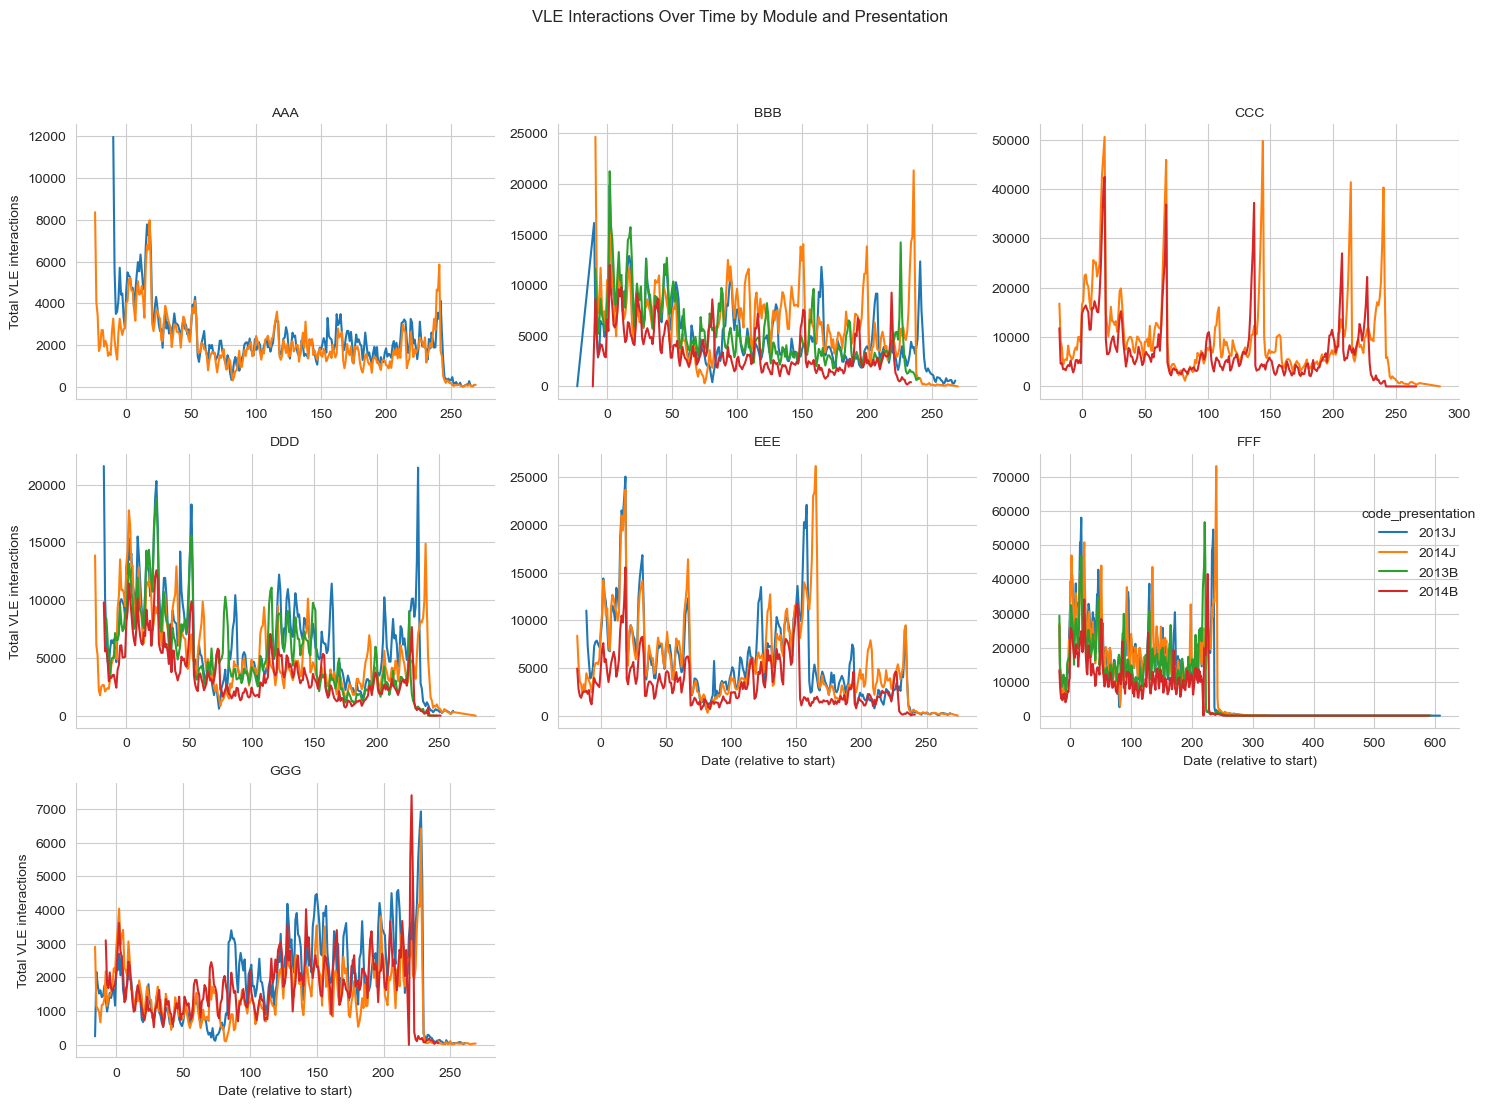

In [31]:
g = sns.relplot(
    data=daily_total_vle,
    x="date",
    y="total_vle",
    hue="code_presentation",   # color by presentation
    kind="line",
    col="code_module",         # one panel per module
    col_wrap=3,                # number of columns before wrapping
    height=3.5,                # height of each facet
    aspect=1.3,                # width-to-height ratio
    facet_kws={"sharey": False, "sharex": False}
)

# Titles and labels
g.set_titles(col_template="{col_name}")
g.set_axis_labels("Date (relative to start)", "Total VLE interactions")
g.fig.suptitle("VLE Interactions Over Time by Module and Presentation", y=1.05)
plt.tight_layout()
plt.show()

In [ ]:
daily_avg_vle = df_vle.groupby(["code_module","code_presentation","date"], as_index=False).agg(avg_vle=("total_vle_interactions", "mean"), num_active_students=("id_student","nunique"))

daily_avg_vle = daily_avg_vle.merge(df_course_students[["code_module","code_presentation","num_unique_students","num_unique_students_firsttime"]], on=["code_module", "code_presentation"], how="left")

daily_avg_vle["percent_active_students"] = daily_avg_vle["num_active_students"]/daily_avg_vle["num_unique_students"]*100

daily_avg_vle.head()

# NB: this includes all students, but I think eventually we only want to include students that have 'num_of_prev_attempts'=0

,code_module,code_presentation,date,avg_vle,num_active_students,num_unique_students,num_unique_students_firsttime,percent_active_students
0,AAA,2013J,-10.0,50.008368,239,378,378,63.227513
1,AAA,2013J,-9.0,27.827586,203,378,378,53.703704
2,AAA,2013J,-8.0,25.727941,136,378,378,35.978836
3,AAA,2013J,-7.0,28.650794,126,378,378,33.333333
4,AAA,2013J,-6.0,30.101449,138,378,378,36.507937


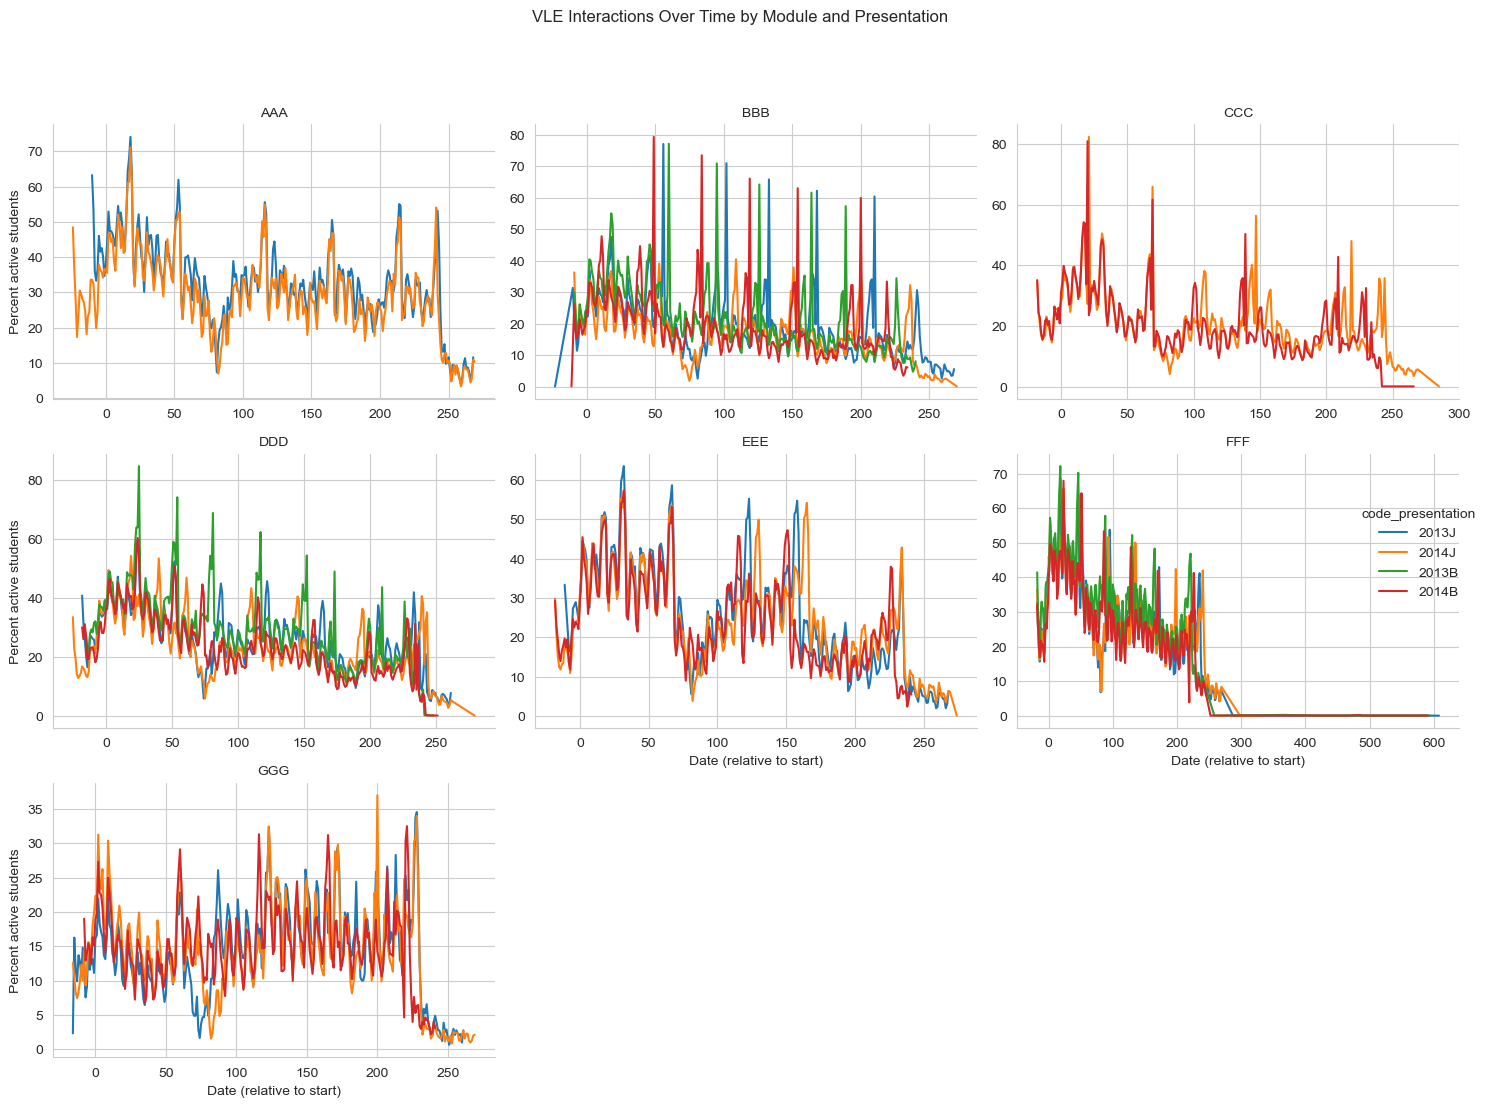

In [39]:
g = sns.relplot(
    data=daily_avg_vle,
    x="date",
    y="percent_active_students",
    hue="code_presentation",   # color by presentation
    kind="line",
    col="code_module",         # one panel per module
    col_wrap=3,                # number of columns before wrapping
    height=3.5,                # height of each facet
    aspect=1.3,                # width-to-height ratio
    facet_kws={"sharey": False, "sharex": False}
)

# Titles and labels
g.set_titles(col_template="{col_name}")
g.set_axis_labels("Date (relative to start)", "Percent active students")
g.fig.suptitle("VLE Interactions Over Time by Module and Presentation", y=1.05)
plt.tight_layout()
plt.show()